# Binary Level Transitions: Analytical Cloud Mass (Julia)

Julia reproduction of `henry/python_wf/binary_level_transitions_plot_analytical_cloud_mass.ipynb`.


In [1]:
using Printf

JULIA_WF_DIR = @__DIR__
if isempty(JULIA_WF_DIR) || !isfile(joinpath(JULIA_WF_DIR, "functions.jl"))
    JULIA_WF_DIR = "/home/cherrytree/bosonSR_repo_/henry/julia_wf"
end
cd(JULIA_WF_DIR)

include(joinpath(JULIA_WF_DIR, "functions.jl"))
using .HenryWF


In [2]:
# Mass that goes into the waveform is eV in calculation, but solar mass as input

M_sol = 0.954e-10
M = M_sol * Msol_in_eV
r = 10000 * 1.5625e23
alpha_val = 0.21
n = 2

l_i, m_i = 1, 1
l_f, m_f = 1, -1

m_boson = alpha_val / (G * M)

q = 1e-3
m_i = 1
m_f = -1
eta = eta_parameter(alpha_val, q, M_sol)
a = a_tilde_crit(m_i, alpha_val)
Omega0 = Omega0_binary_natural_unit(m_i, alpha_val, G, M, n, l_i)
gamma = gamma_rate(q, M, Omega0)
Gamma_abs = abs(imag(find_cf_root(M_sol, a, m_boson, n, l_i, m_f))) * rg(M_sol) / (G * M)

Hz_per_eV = 2.417987242e14
Omega0_Hz = Omega0 * Hz_per_eV
f = collect(range(8e7, 2e9, length=100000))

h_of_iota = htilde_plus(
    f ./ Hz_per_eV, M, r, alpha_val, Omega0, q, m_i, m_f, eta, Gamma_abs;
    use_z_scaling=false, numerical_qc=false,
)

println("Boson Mass is: $(m_boson) eV \n")
println("BH Mass is: $(M / Msol_in_eV) solar masses\n")
@printf("Omega0 is: %.3g Hz\n", Omega0_Hz)
@printf("gamma is: %.3g Hz\n", gamma)
println("Eta is: $(eta)")
println("Instablity rate is:$(Gamma_abs)")
println("Mass is: $(M)")
println("z is: $(z_parameter(eta, 2, gamma))")
println("peak frequency is: $((fc_from_Omega0(Omega0) - 2 * z_parameter(eta, 2, gamma) * Gamma_abs / pi) * Hz_per_eV)Hz")
println("numerical clould_mass_ratio is: unavailable in the Julia port; Python uses table-backed RelScalar data")
println("analytical clould_mass_ratio is: $(q_c(alpha_val, m_i))")

iota = pi / 2
Hf = h_of_iota(iota);


Boson Mass is: 0.2926837837850054 eV 

BH Mass is: 9.54e-11 solar masses

Omega0 is: 1.72e+09 Hz
gamma is: 1.47e-21 Hz
Eta is: 3.52409410811083e-11
Instablity rate is:3.809098145151282e-7
Mass is: 1.0694825599594304e56
z is: 0.4227343037284684
peak frequency is: 1.0701075423683808e9Hz
numerical clould_mass_ratio is: unavailable in the Julia port; Python uses table-backed RelScalar data
analytical clould_mass_ratio is: 0.10638454965488653


In [3]:
function line_plot_svg(x, y; width=900, height=540, xlabel="f (Hz)", ylabel="|H(f)|")
    x = Float64.(x)
    y = Float64.(y)
    xmin, xmax = extrema(x)
    ymin, ymax = extrema(y)
    ymin = min(0.0, ymin)
    ymax = ymax == ymin ? ymin + 1.0 : ymax

    left, right, top, bottom = 82.0, 24.0, 24.0, 68.0
    plot_w = width - left - right
    plot_h = height - top - bottom
    sx(v) = left + (v - xmin) / (xmax - xmin) * plot_w
    sy(v) = top + (1.0 - (v - ymin) / (ymax - ymin)) * plot_h

    npoints = min(length(x), 1600)
    idx = unique(round.(Int, range(1, length(x), length=npoints)))
    points = join(("$(round(sx(x[i]), digits=2)),$(round(sy(y[i]), digits=2))" for i in idx), " " )

    xticks = collect(range(xmin, xmax, length=5))
    yticks = collect(range(ymin, ymax, length=5))

    parts = String[]
    push!(parts, "<svg xmlns='http://www.w3.org/2000/svg' width='$width' height='$height' viewBox='0 0 $width $height'>")
    push!(parts, "<rect width='100%' height='100%' fill='white'/>")
    push!(parts, "<rect x='$left' y='$top' width='$plot_w' height='$plot_h' fill='none' stroke='#222' stroke-width='1'/>")

    for t in xticks
        xpix = sx(t)
        push!(parts, "<line x1='$xpix' y1='$top' x2='$xpix' y2='$(top + plot_h)' stroke='#ddd' stroke-dasharray='2,3'/>")
        push!(parts, "<text x='$xpix' y='$(height - 34)' text-anchor='middle' font-size='12' fill='#333'>$(round(t, sigdigits=3))</text>")
    end

    for t in yticks
        ypix = sy(t)
        push!(parts, "<line x1='$left' y1='$ypix' x2='$(left + plot_w)' y2='$ypix' stroke='#ddd' stroke-dasharray='2,3'/>")
        push!(parts, "<text x='$(left - 10)' y='$(ypix + 4)' text-anchor='end' font-size='12' fill='#333'>$(round(t, sigdigits=3))</text>")
    end

    push!(parts, "<polyline points='$points' fill='none' stroke='#1f77b4' stroke-width='2'/>")
    push!(parts, "<text x='$(left + plot_w / 2)' y='$(height - 10)' text-anchor='middle' font-size='14' fill='#222'>$xlabel</text>")
    push!(parts, "<text transform='translate(18,$(top + plot_h / 2)) rotate(-90)' text-anchor='middle' font-size='14' fill='#222'>$ylabel</text>")
    push!(parts, "</svg>")
    return join(parts, "\n")
end


line_plot_svg (generic function with 1 method)

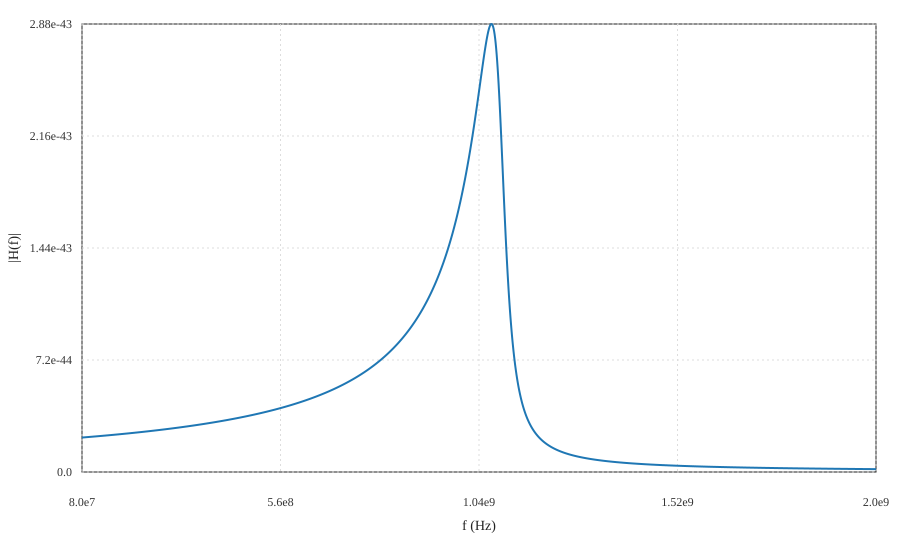

In [4]:
struct InlineSVG
    data::String
end

Base.show(io::IO, ::MIME"image/svg+xml", svg::InlineSVG) = print(io, svg.data)
Base.show(io::IO, ::MIME"text/plain", ::InlineSVG) = print(io, "Inline SVG plot")

svg = line_plot_svg(f, abs.(Hf))
display(InlineSVG(svg))
